Loaded studentInfo: 32,593 rows

Overall dropout rate: 31.2%

RUNNING CHI-SQUARE TESTS
  H0: Feature and dropout are independent
  Significance threshold: p < 0.05

  Feature: gender
    χ²  = 5.734   (dof=1)
    p   = 1.6641e-02
    V   = 0.0133  (negligible effect)
    n   = 32,593  (0 rows dropped for missing values)
    ✅ SIGNIFICANT

  Feature: age_band
    χ²  = 38.281   (dof=2)
    p   = 4.8692e-09
    V   = 0.0343  (negligible effect)
    n   = 32,593  (0 rows dropped for missing values)
    ✅ SIGNIFICANT

  Feature: highest_education
    χ²  = 202.223   (dof=4)
    p   = 1.2498e-42
    V   = 0.0788  (negligible effect)
    n   = 32,593  (0 rows dropped for missing values)
    ✅ SIGNIFICANT

  Feature: imd_band
    χ²  = 200.214   (dof=9)
    p   = 2.9875e-38
    V   = 0.0797  (negligible effect)
    n   = 31,482  (1,111 rows dropped for missing values)
    ✅ SIGNIFICANT

  Feature: disability
    χ²  = 109.123   (dof=1)
    p   = 1.5253e-25
    V   = 0.0579  (negligible effect

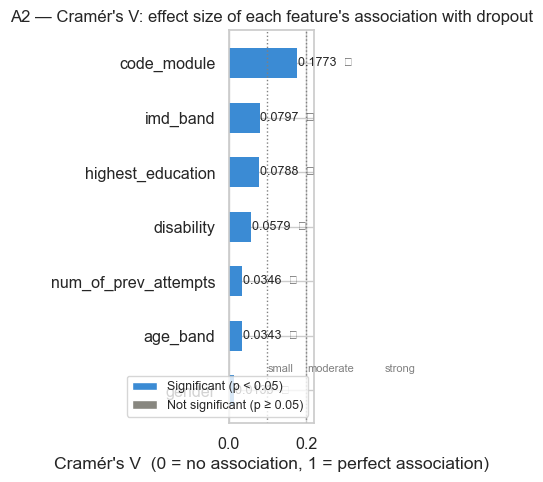

  Saved → ./outputs/phase3/block_a/A2_cramers_v_ranking.png

A3: Plotting -log10(p-value) chart...


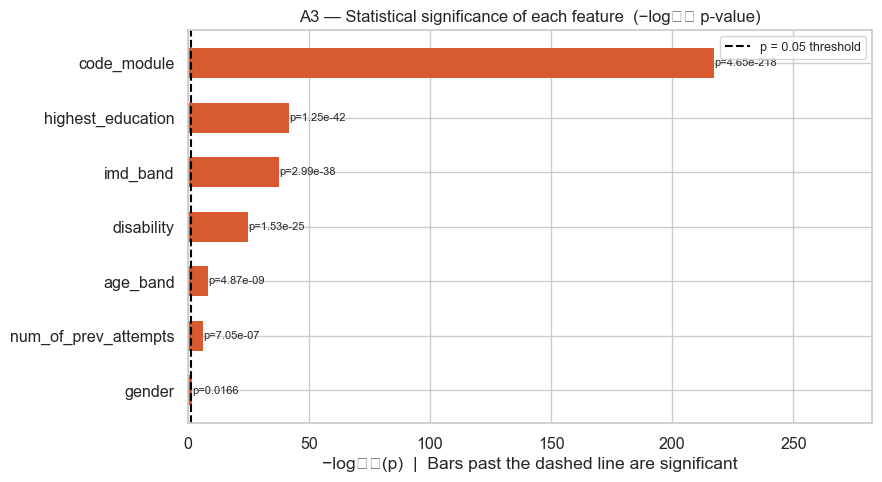

  Saved → ./outputs/phase3/block_a/A3_pvalue_ranking.png

A4: Contingency table heatmaps for top 3 features by Cramér's V...


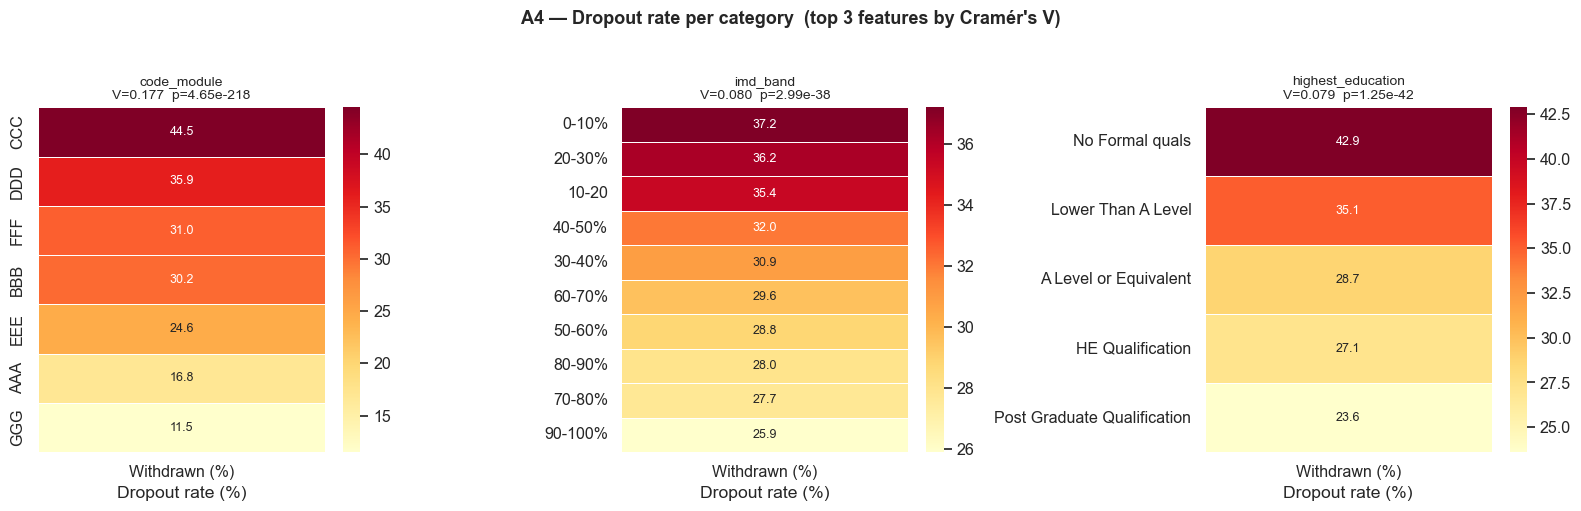

  Saved → ./outputs/phase3/block_a/A4_contingency_heatmaps.png

A5: Checking chi-square assumption (expected frequencies ≥ 5)...

  gender                         0/4 cells < 5  (0.0%)  →  ✅ OK
  age_band                       0/6 cells < 5  (0.0%)  →  ✅ OK
  highest_education              0/10 cells < 5  (0.0%)  →  ✅ OK
  imd_band                       0/20 cells < 5  (0.0%)  →  ✅ OK
  disability                     0/4 cells < 5  (0.0%)  →  ✅ OK
  num_of_prev_attempts           3/14 cells < 5  (21.4%)  →  ⚠  VIOLATED
  code_module                    0/14 cells < 5  (0.0%)  →  ✅ OK

  Note: If the assumption is violated, consider:
    • Merging small categories
    • Using Fisher's exact test (for 2×2 tables)
    • Using G-test (likelihood ratio chi-square)

BLOCK A COMPLETE — Chi-Square Test Results

  Features tested          : 7
  Significant (p < 0.05)   : 7  → ['gender', 'age_band', 'highest_education', 'imd_band', 'disability', 'num_of_prev_attempts', 'code_module']
  Not signif

In [1]:
"""
=============================================================
Phase 3 — Block A: Chi-Square Tests
=============================================================
Goal: Formally test whether each categorical feature's association
      with dropout is statistically significant — or just noise.

What is a chi-square test?
  A chi-square (χ²) test checks whether two categorical variables
  are INDEPENDENT of each other.

  H0 (null hypothesis)  : The feature and dropout are independent
                          (no real association).
  H1 (alt hypothesis)   : The feature and dropout are NOT independent
                          (a real association exists).

  If p < 0.05 → reject H0 → the association is statistically significant.
  If p ≥ 0.05 → fail to reject H0 → no significant association found.

What is Cramér's V?
  p-values only tell you IF an association is real.
  Cramér's V tells you HOW STRONG it is (effect size):
    V < 0.10  → negligible
    V = 0.10–0.20 → small
    V = 0.20–0.40 → moderate
    V > 0.40  → strong

  Formula: V = sqrt(χ² / (n × (k − 1)))
    where n = sample size, k = min(rows, cols) in the contingency table.

Features tested:
  gender, age_band, highest_education, imd_band,
  disability, num_of_prev_attempts, code_module
"""

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/phase3/block_a/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

print(f"Loaded studentInfo: {si.shape[0]:,} rows\n")
print(f"Overall dropout rate: {si['dropout'].mean()*100:.1f}%\n")


# =============================================================
# HELPER: run_chi_square
# =============================================================
# Runs a full chi-square analysis for one feature vs dropout.
# Returns a results dict with χ², p-value, dof, and Cramér's V.

def run_chi_square(df, feature, target='dropout'):
    """
    Run a chi-square test for independence between `feature` and `target`.

    Steps:
      1. Drop rows where the feature is missing (NaN)
      2. Build a contingency table (cross-tabulation)
      3. Run scipy's chi2_contingency()
      4. Compute Cramér's V (effect size)
      5. Return all results as a dict
    """

    # Step 1: drop missing values for this feature
    clean = df[[feature, target]].dropna()
    n_dropped = len(df) - len(clean)

    # Step 2: contingency table
    # Rows = feature categories, Columns = dropout (0 or 1)
    contingency = pd.crosstab(clean[feature], clean[target])

    # Step 3: chi-square test
    # chi2_contingency returns:
    #   chi2    = the test statistic
    #   p       = the p-value
    #   dof     = degrees of freedom = (rows-1) × (cols-1)
    #   expected= expected frequencies under H0 (independence)
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Step 4: Cramér's V (effect size)
    # n = total observations, k = min(rows, cols) in the table
    n = len(clean)
    k = min(contingency.shape) - 1            # min(rows, cols) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

    # Interpret effect size
    if cramers_v < 0.10:
        effect = 'negligible'
    elif cramers_v < 0.20:
        effect = 'small'
    elif cramers_v < 0.40:
        effect = 'moderate'
    else:
        effect = 'strong'

    # Significance flag
    significant = p < 0.05

    return {
        'feature':      feature,
        'chi2':         round(chi2, 3),
        'p_value':      p,
        'dof':          dof,
        'cramers_v':    round(cramers_v, 4),
        'effect_size':  effect,
        'significant':  significant,
        'n':            n,
        'n_dropped':    n_dropped,
        'contingency':  contingency,
        'expected':     expected,
    }


# =============================================================
# A1: Run chi-square for every categorical feature
# =============================================================

# Define which features to test and their display order
# num_of_prev_attempts is technically numeric but has few unique values
# so it behaves like a categorical variable here — valid for chi-square
categorical_features = [
    'gender',
    'age_band',
    'highest_education',
    'imd_band',
    'disability',
    'num_of_prev_attempts',
    'code_module',
]

print("=" * 60)
print("RUNNING CHI-SQUARE TESTS")
print("=" * 60)
print(f"  H0: Feature and dropout are independent")
print(f"  Significance threshold: p < 0.05\n")

results = []

for feature in categorical_features:
    r = run_chi_square(si, feature)
    results.append(r)

    sig_label = "✅ SIGNIFICANT" if r['significant'] else "⚠  not significant"

    print(f"  Feature: {feature}")
    print(f"    χ²  = {r['chi2']:.3f}   (dof={r['dof']})")
    print(f"    p   = {r['p_value']:.4e}")
    print(f"    V   = {r['cramers_v']:.4f}  ({r['effect_size']} effect)")
    print(f"    n   = {r['n']:,}  ({r['n_dropped']:,} rows dropped for missing values)")
    print(f"    {sig_label}")
    print()

# Collect into a clean summary DataFrame
results_df = pd.DataFrame([{
    'Feature':      r['feature'],
    'χ²':           r['chi2'],
    'p-value':      r['p_value'],
    'DoF':          r['dof'],
    "Cramér's V":   r['cramers_v'],
    'Effect size':  r['effect_size'],
    'Significant':  '✅ Yes' if r['significant'] else '⚠ No',
} for r in results])

print("\nSummary table:")
print(results_df.to_string(index=False))
print()


# =============================================================
# A2: Visualise — Cramér's V bar chart (effect size ranking)
# =============================================================
# Cramér's V tells us the PRACTICAL importance of each association.
# We sort features by V so the most important ones are at the top.

print("A2: Plotting Cramér's V (effect size) chart...")

# Sort by Cramér's V descending for the chart
v_sorted = results_df.sort_values("Cramér's V", ascending=True)

# Colour bars by significance: significant = blue, not = gray
bar_colors = [
    COLORS['blue'] if sig == '✅ Yes' else COLORS['gray']
    for sig in v_sorted['Significant']
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    v_sorted['Feature'],
    v_sorted["Cramér's V"],
    color=bar_colors,
    edgecolor='none',
    height=0.55
)

# Add value labels at end of each bar
for bar, val, sig in zip(bars, v_sorted["Cramér's V"], v_sorted['Significant']):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}  {'✅' if sig == '✅ Yes' else '⚠'}",
        va='center', fontsize=9
    )

# Reference lines for effect size thresholds
for threshold, label in [(0.10, 'small'), (0.20, 'moderate'), (0.40, 'strong')]:
    ax.axvline(threshold, color='gray', linestyle=':', linewidth=1)
    ax.text(threshold + 0.002, 0.3, label, fontsize=8, color='gray', va='bottom')

ax.set_title("A2 — Cramér's V: effect size of each feature's association with dropout",
             fontsize=12)
ax.set_xlabel("Cramér's V  (0 = no association, 1 = perfect association)")
ax.set_xlim(0, v_sorted["Cramér's V"].max() * 1.25)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['blue'], label='Significant (p < 0.05)'),
    Patch(facecolor=COLORS['gray'], label='Not significant (p ≥ 0.05)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "A2_cramers_v_ranking.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# A3: Heatmap of p-values
# =============================================================
# A -log10(p) transformation makes small p-values visually large.
# p = 0.05 → -log10(0.05) = 1.30  (our significance threshold)
# p = 0.001 → -log10(0.001) = 3.0  (stronger evidence)
# This lets us compare significance strength across all features at once.

print("A3: Plotting -log10(p-value) chart...")

results_df['-log10(p)'] = -np.log10(results_df['p-value'].clip(lower=1e-300))

pval_sorted = results_df.sort_values('-log10(p)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

# Colour by significance
bar_colors_p = [
    COLORS['coral'] if sig == '✅ Yes' else COLORS['gray']
    for sig in pval_sorted['Significant']
]

bars_p = ax.barh(
    pval_sorted['Feature'],
    pval_sorted['-log10(p)'],
    color=bar_colors_p,
    edgecolor='none',
    height=0.55
)

# Significance threshold line at p = 0.05 → -log10(0.05) = 1.30
threshold_line = -np.log10(0.05)
ax.axvline(threshold_line, color='black', linestyle='--', linewidth=1.5,
           label='p = 0.05 threshold')

# Add p-value labels
for bar, p_val in zip(bars_p, pval_sorted['p-value']):
    label = f"p={p_val:.2e}" if p_val < 0.001 else f"p={p_val:.4f}"
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=8
    )

ax.set_title("A3 — Statistical significance of each feature  (−log₁₀ p-value)",
             fontsize=12)
ax.set_xlabel("−log₁₀(p)  |  Bars past the dashed line are significant")
ax.legend(fontsize=9)
ax.set_xlim(0, pval_sorted['-log10(p)'].max() * 1.3)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "A3_pvalue_ranking.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# A4: Contingency table heatmaps for top 3 features
# =============================================================
# A contingency table heatmap shows the PATTERN of association
# visually. The cells show dropout RATE per category level — the
# darker the cell, the higher the dropout rate in that group.

print("A4: Contingency table heatmaps for top 3 features by Cramér's V...")

# Pick the top 3 features by Cramér's V
top3 = results_df.nlargest(3, "Cramér's V")['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, top3):

    # Build a dropout RATE table (not raw counts)
    # This normalises for unequal group sizes — each cell = % who withdrew
    rate_table = (
        si.dropna(subset=[feature])
          .groupby(feature)['dropout']
          .mean()
          .mul(100)
          .round(1)
          .to_frame()
          .T      # transpose so feature categories are columns
    )

    # For multi-category features, build a proper pivot
    ct = pd.crosstab(
        si.dropna(subset=[feature])[feature],
        si.dropna(subset=[feature])['dropout'],
        normalize='index'   # normalise by row → gives dropout rate per group
    ).mul(100).round(1)

    # Rename columns for readability
    ct.columns = ['Not withdrawn (%)', 'Withdrawn (%)']

    # Plot heatmap of just the "Withdrawn (%)" column
    withdrawn_rates = ct[['Withdrawn (%)']].sort_values('Withdrawn (%)', ascending=False)

    v_score = results_df[results_df['Feature'] == feature]["Cramér's V"].values[0]
    p_val   = results_df[results_df['Feature'] == feature]['p-value'].values[0]

    sns.heatmap(
        withdrawn_rates,
        ax=ax,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',          # yellow = low dropout, red = high dropout
        cbar=True,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9}
    )

    ax.set_title(
        f"{feature}\nV={v_score:.3f}  p={p_val:.2e}",
        fontsize=10
    )
    ax.set_xlabel("Dropout rate (%)")
    ax.set_ylabel("")

plt.suptitle(
    "A4 — Dropout rate per category  (top 3 features by Cramér's V)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "A4_contingency_heatmaps.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# A5: Assumption check — expected cell frequencies
# =============================================================
# Chi-square requires that expected cell frequencies are ≥ 5 in
# at least 80% of cells. We check this for every feature and flag
# any that might violate the assumption.

print("A5: Checking chi-square assumption (expected frequencies ≥ 5)...")
print()

for r in results:
    expected     = r['expected']
    n_cells      = expected.size
    n_below_5    = (expected < 5).sum()
    pct_below_5  = n_below_5 / n_cells * 100
    assumption_ok = pct_below_5 <= 20   # chi-square is robust if ≤20% cells < 5

    status = "✅ OK" if assumption_ok else "⚠  VIOLATED"
    print(f"  {r['feature']:<30} {n_below_5}/{n_cells} cells < 5  "
          f"({pct_below_5:.1f}%)  →  {status}")

print()
print("  Note: If the assumption is violated, consider:")
print("    • Merging small categories")
print("    • Using Fisher's exact test (for 2×2 tables)")
print("    • Using G-test (likelihood ratio chi-square)")
print()


# =============================================================
# BLOCK A SUMMARY
# =============================================================
sig_features     = results_df[results_df['Significant'] == '✅ Yes']['Feature'].tolist()
non_sig_features = results_df[results_df['Significant'] == '⚠ No']['Feature'].tolist()
top_feature      = results_df.loc[results_df["Cramér's V"].idxmax(), 'Feature']
top_v            = results_df["Cramér's V"].max()

print("=" * 60)
print("BLOCK A COMPLETE — Chi-Square Test Results")
print("=" * 60)
print(f"""
  Features tested          : {len(categorical_features)}
  Significant (p < 0.05)   : {len(sig_features)}  → {sig_features}
  Not significant          : {len(non_sig_features)}  → {non_sig_features}

  Strongest association    : {top_feature}  (V = {top_v:.4f})

  Key takeaway:
  → Significant features will be included in the logistic regression (Block C).
  → Non-significant features may still be included as controls but are not
    primary risk factors.

  Charts saved to: {OUTPUT_PATH}
    A2_cramers_v_ranking.png
    A3_pvalue_ranking.png
    A4_contingency_heatmaps.png

─────────────────────────────────────────────────────────
Next → Run phase3_block_b_ttests.py
─────────────────────────────────────────────────────────
""")